### About Dataset
#### Context
Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs.

Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## EDA 

In [34]:
df = pd.read_csv('..\\data\\raw\\Telco-Customer-Churn.csv')

In [35]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [37]:
df['OnlineSecurity'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [38]:
cols = df.select_dtypes(include='object').columns

yes_no_columns = {'No', 'Yes'}
yes_no_internet_columns = {'No', 'Yes', 'No internet service'}

print("YES NO columns:")
for c in cols:
    if set(df[c].dropna().unique()) == yes_no_columns:
        print(c)
print("\nYES NO No_internet_service columns:")
for c in cols:
    if set(df[c].dropna().unique()) == yes_no_internet_columns:
        print(c)

YES NO columns:
Partner
Dependents
PhoneService
PaperlessBilling
Churn

YES NO No_internet_service columns:
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies


C:\Users\user\AppData\Local\Temp\ipykernel_2548\2730092427.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = df.select_dtypes(include='object').columns


In [39]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [40]:
df = df.drop('customerID', axis=1)

In [41]:
df.loc[df['TotalCharges'] == ' ', 'TotalCharges'] = '0'

In [42]:
df[df['TotalCharges'] == ' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [43]:
df['TotalCharges'] = df['TotalCharges'].apply(float)

In [44]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
for column in df.select_dtypes(include='str').columns:
    print(f'{column}: {df[column].unique().tolist()}')

gender: ['Female', 'Male']
Partner: ['Yes', 'No']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No phone service', 'No', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'Yes', 'No internet service']
OnlineBackup: ['Yes', 'No', 'No internet service']
DeviceProtection: ['No', 'Yes', 'No internet service']
TechSupport: ['No', 'Yes', 'No internet service']
StreamingTV: ['No', 'Yes', 'No internet service']
StreamingMovies: ['No', 'Yes', 'No internet service']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['Yes', 'No']
PaymentMethod: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Churn: ['No', 'Yes']


In [46]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   gender_Male                            7043 non-null   int64  
 5   Partner_Yes                            7043 non-null   int64  
 6   Dependents_Yes                         7043 non-null   int64  
 7   PhoneService_Yes                       7043 non-null   int64  
 8   MultipleLines_No phone service         7043 non-null   int64  
 9   MultipleLines_Yes                      7043 non-null   int64  
 10  InternetService_Fiber optic            7043 non-null   int64  
 11  InternetService

In [48]:
df.to_csv('..\\data\\processed\\cleaned.csv', index=False)

## Featrue engineering

In [27]:
df = pd.read_csv('..\\data\\processed\\cleaned.csv')

<Axes: >

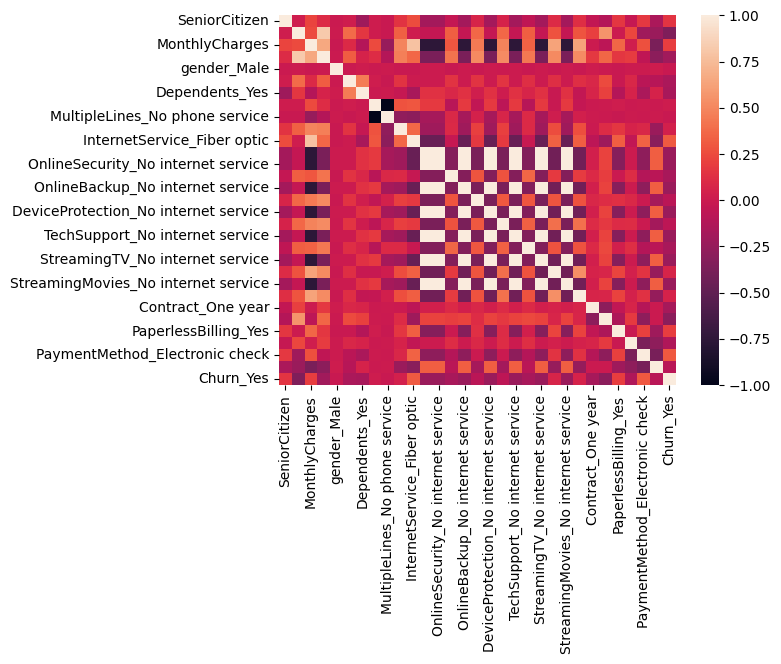

In [28]:
corr_matrix = df.corr()

sns.heatmap(corr_matrix)

Text(0.5, 1.0, 'Churn correlation')

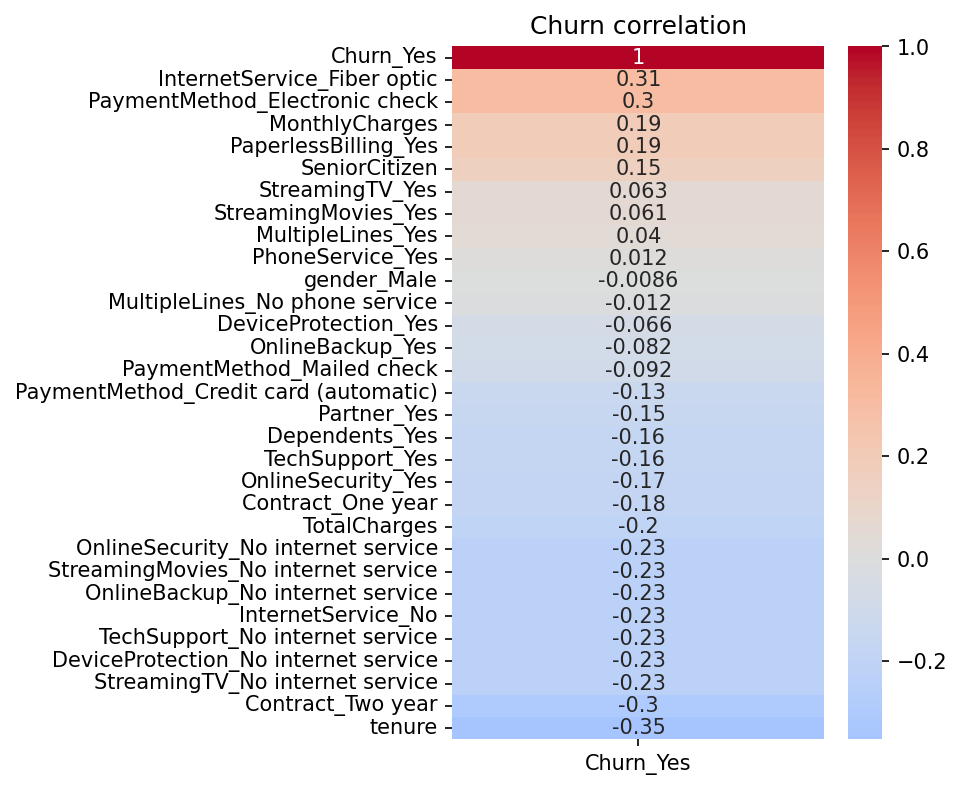

In [29]:
churn_corr = corr_matrix['Churn_Yes'].sort_values(ascending=False)

plt.figure(figsize=(4,6), dpi=150)
sns.heatmap(churn_corr.to_frame(), center=0, cmap='coolwarm', annot=True)
plt.title('Churn correlation')

In [30]:
df['InternetService_No'] = (
    df['OnlineSecurity_No internet service'] |
    df['StreamingMovies_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['TechSupport_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['StreamingTV_No internet service'] | 
    df['InternetService_No']
).astype(int)

drop_columns = [col for col in df.columns if 'No internet service' in col]
df = df.drop(drop_columns, axis=1)

## Machine Learning

In [21]:
df['Churn_Yes'].value_counts()

Churn_Yes
0    5174
1    1869
Name: count, dtype: int64

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)

THRESHOLD = 0.35

In [47]:
model = RandomForestClassifier(class_weight='balanced', max_depth=3, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = (model.predict_proba(X_test)[:,1] >= THRESHOLD)
print(classification_report(y_test, y_pred))
#ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.95      0.48      0.63      1035
           1       0.39      0.93      0.55       374

    accuracy                           0.59      1409
   macro avg       0.67      0.70      0.59      1409
weighted avg       0.80      0.59      0.61      1409



In [48]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, max_depth=6, n_jobs=-1, learning_rate=0.05)

xgb.fit(X_train, y_train)
y_pred = (xgb.predict_proba(X_test)[:,1] >= THRESHOLD)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.62      0.74      1035
           1       0.44      0.84      0.58       374

    accuracy                           0.68      1409
   macro avg       0.68      0.73      0.66      1409
weighted avg       0.79      0.68      0.70      1409



In [34]:
import optuna
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_score

study_X_train, study_X_val, study_y_train, study_y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=101, stratify=y_train)

def recall_with_threshold(estimator, X_val : pd.DataFrame, y_val : pd.Series) -> float:
    """
    Implements threshold to recall_score to focus on positive class.
    """
    pred = estimator.predict_proba(X_val)[:, 1]

    y_pred = (pred >= THRESHOLD).astype(int)

    return recall_score(y_val, y_pred, zero_division=0)

def objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators" : trial.suggest_int("n_estimators", 200, 800),
        "learning_rate" : trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth" : trial.suggest_int("max_depth", 3, 10),
        "min_child_weight" : trial.suggest_int( "min_child_weight", 1, 10),
        "subsample" : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma" : trial.suggest_float( "gamma", 0.0, 5.0), 
        "reg_alpha" : trial.suggest_float( "reg_alpha", 1e-8, 10.0, log=True), 
        "reg_lambda" : trial.suggest_float( "reg_lambda", 1e-8, 10.0, log=True),

        "scale_pos_weight" : scale_pos_weight,
        "random_state" : 42,
        "n_jobs" : -1,
        "eval_metric" : "logloss"
    }

    model = XGBClassifier(**params)
    scores = cross_val_score(model, study_X_train, study_y_train, cv=5, scoring=recall_with_threshold, n_jobs=1)

    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-09-19 09:31:13,206] A new study created in memory with name: no-name-e61f580c-9f76-44c1-b506-b4a1bc76fccd
[I 2026-09-19 09:31:26,355] Trial 0 finished with value: 0.7457845188284519 and parameters: {'n_estimators': 750, 'learning_rate': 0.02369722682770678, 'max_depth': 5, 'min_child_weight': 2, 'subsample': 0.7954510220717694, 'colsample_bytree': 0.813733526414297, 'gamma': 1.7354824248634397, 'reg_alpha': 0.0004468920934737049, 'reg_lambda': 0.0012355424391580338}. Best is trial 0 with value: 0.7457845188284519.
[I 2026-09-19 09:31:36,939] Trial 1 finished with value: 0.7524790794979079 and parameters: {'n_estimators': 582, 'learning_rate': 0.02145102698238797, 'max_depth': 10, 'min_child_weight': 6, 'subsample': 0.527620691986499, 'colsample_bytree': 0.6881358817928549, 'gamma': 3.624051130589012, 'reg_alpha': 0.0015803041485368216, 'reg_lambda': 0.044616368587273435}. Best is trial 1 with value: 0.7524790794979079.
[I 2026-09-19 09:31:42,085] Trial 2 finished with value: 0.

Best Score: 0.8118410041841004
Best Params: {'n_estimators': 379, 'learning_rate': 0.016358039076889385, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.6905280485184822, 'colsample_bytree': 0.5015738802518205, 'gamma': 4.93745875549078, 'reg_alpha': 1.9084896603996836e-08, 'reg_lambda': 8.875723555260352}


In [38]:
import optuna
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_score

study_X_train, study_X_val, study_y_train, study_y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=101, stratify=y_train)

def recall_with_threshold(estimator, X_val : pd.DataFrame, y_val : pd.Series) -> float:
    """
    Implements threshold to recall_score to focus on positive class.
    """
    pred = estimator.predict_proba(X_val)[:, 1]

    y_pred = (pred >= THRESHOLD).astype(int)

    return recall_score(y_val, y_pred, zero_division=0)

def objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators" : trial.suggest_int("n_estimators", 200, 800),
        "max_depth" : trial.suggest_int("max_depth", 3, 10),
        "min_samples_split" : trial.suggest_int( "min_samples_split", 2, 20),
        "min_samples_leaf" : trial.suggest_int( "min_samples_leaf", 1, 10),
        "max_features" : trial.suggest_float( "max_features", 0.3, 1),
        "max_samples" : trial.suggest_float( "max_samples", 0.5, 1),
        "class_weight" : trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),

        "random_state" : 42,
        "n_jobs" : -1
    }

    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, study_X_train, study_y_train, cv=5, scoring=recall_with_threshold, n_jobs=1)

    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-09-19 10:24:33,490] A new study created in memory with name: no-name-7643f85d-7a76-4c80-b0d4-4c28422d8a1d


[I 2026-09-19 10:25:17,318] Trial 0 finished with value: 0.7340934449093446 and parameters: {'n_estimators': 760, 'max_depth': 9, 'min_samples_split': 19, 'min_samples_leaf': 7, 'max_features': 0.9436815833869281, 'max_samples': 0.9356726297809996, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.7340934449093446.
[I 2026-09-19 10:25:48,564] Trial 1 finished with value: 0.7608437935843794 and parameters: {'n_estimators': 743, 'max_depth': 6, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 0.9247944408513515, 'max_samples': 0.8851580635441807, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.7608437935843794.
[I 2026-09-19 10:26:02,645] Trial 2 finished with value: 0.709850069735007 and parameters: {'n_estimators': 322, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.47506377901015207, 'max_samples': 0.9885641907105964, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.7608437935843794.
[I 2026-09-1

Best Score: 0.8034937238493726
Best Params: {'n_estimators': 571, 'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 0.45018223045464767, 'max_samples': 0.5985166720227304, 'class_weight': 'balanced_subsample'}


In [49]:
best_params = {
    'n_estimators': 379, 
    'learning_rate': 0.016358039076889385, 
    'max_depth': 3, 
    'min_child_weight': 8, 
    'subsample': 0.6905280485184822, 
    'colsample_bytree': 0.5015738802518205, 
    'gamma': 4.93745875549078, 
    'reg_alpha': 1.9084896603996836e-08, 
    'reg_lambda': 8.875723555260352,
    'scale_pos_weight': scale_pos_weight
}
model = XGBClassifier(**best_params)
model.fit(X_train, y_train)
pred = model.predict_proba(X_test)[:, 1]
y_pred = (pred >= THRESHOLD).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.58      0.72      1035
           1       0.43      0.87      0.58       374

    accuracy                           0.66      1409
   macro avg       0.68      0.73      0.65      1409
weighted avg       0.79      0.66      0.68      1409



In [50]:
best_params = {
    'n_estimators': 571, 
    'max_depth': 3, 
    'min_samples_leaf': 9, 
    'max_features': 0.45018223045464767, 
    'max_samples': 0.5985166720227304, 
    'class_weight': 'balanced_subsample',
    'n_jobs': -1
    }
model = RandomForestClassifier(**study.best_params)
model.fit(X_train, y_train)
pred = model.predict_proba(X_test)[:, 1]
y_pred = (pred >= THRESHOLD).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.50      0.66      1035
           1       0.40      0.91      0.55       374

    accuracy                           0.61      1409
   macro avg       0.67      0.71      0.60      1409
weighted avg       0.80      0.61      0.63      1409

